# Model - uncertainty2

This example shows how to use `lmfit_global.LmfitGlobal` class & `lmfit_global.simplefit` to fit data and evaluate uncertainty. 

This example is similar to `model_uncertainty_pred.py` of [lmfit examples](https://lmfit.github.io/lmfit-py/examples/index.html) or [github link](https://github.com/lmfit/lmfit-py/tree/master/examples)

In [ ]:
try:
    from lmfit_global import LmfitGlobal, simplefit
    from lmfit_global.utils.builders import GlobalFitBuilder
except (ImportError, ModuleNotFoundError):
    import os, sys
    ROOT = os.path.abspath("..")  # parent of examples
    sys.path.insert(0, ROOT)

    from lmfit_global import LmfitGlobal, simplefit
    from lmfit_global.utils.builders import GlobalFitBuilder

import matplotlib
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
tlen = np.array([3.6, 1.8, 3.333, 2.283, 4.533, 2.883, 4.7, 3.6, 1.95, 4.35,
                 1.833, 3.917, 4.2, 1.75, 4.7, 2.167, 1.75, 4.8, 1.6, 4.25,
                 1.8, 1.75, 3.45, 3.067, 4.533, 3.6, 1.967, 4.083, 3.85, 4.433,
                 4.3, 4.467, 3.367, 4.033, 3.833, 2.017, 1.867, 4.833, 1.833,
                 4.783, 4.35, 1.883, 4.567, 1.75, 4.533, 3.317, 3.833, 2.1,
                 4.633, 2, 4.8, 4.716, 1.833, 4.833, 1.733, 4.883, 3.717,
                 1.667, 4.567, 4.317, 2.233, 4.5, 1.75, 4.8, 1.817, 4.4, 4.167,
                 4.7, 2.067, 4.7, 4.033, 1.967, 4.5, 4, 1.983, 5.067, 2.017,
                 4.567, 3.883, 3.6, 4.133, 4.333, 4.1, 2.633, 4.067, 4.933,
                 3.95, 4.517, 2.167, 4, 2.2, 4.333, 1.867, 4.817, 1.833, 4.3,
                 4.667, 3.75, 1.867, 4.9, 2.483, 4.367, 2.1, 4.5, 4.05, 1.867,
                 4.7, 1.783, 4.85, 3.683, 4.733, 2.3, 4.9, 4.417, 1.7, 4.633,
                 2.317, 4.6, 1.817, 4.417, 2.617, 4.067, 4.25, 1.967, 4.6,
                 3.767, 1.917, 4.5, 2.267, 4.65, 1.867, 4.167, 2.8, 4.333,
                 1.833, 4.383, 1.883, 4.933, 2.033, 3.733, 4.233, 2.233, 4.533,
                 4.817, 4.333, 1.983, 4.633, 2.017, 5.1, 1.8, 5.033, 4, 2.4,
                 4.6, 3.567, 4, 4.5, 4.083, 1.8, 3.967, 2.2, 4.15, 2, 3.833,
                 3.5, 4.583, 2.367, 5, 1.933, 4.617, 1.917, 2.083, 4.583,
                 3.333, 4.167, 4.333, 4.5, 2.417, 4, 4.167, 1.883, 4.583, 4.25,
                 3.767, 2.033, 4.433, 4.083, 1.833, 4.417, 2.183, 4.8, 1.833,
                 4.8, 4.1, 3.966, 4.233, 3.5, 4.366, 2.25, 4.667, 2.1, 4.35,
                 4.133, 1.867, 4.6, 1.783, 4.367, 3.85, 1.933, 4.5, 2.383, 4.7,
                 1.867, 3.833, 3.417, 4.233, 2.4, 4.8, 2, 4.15, 1.867, 4.267,
                 1.75, 4.483, 4, 4.117, 4.083, 4.267, 3.917, 4.55, 4.083,
                 2.417, 4.183, 2.217, 4.45, 1.883, 1.85, 4.283, 3.95, 2.333,
                 4.15, 2.35, 4.933, 2.9, 4.583, 3.833, 2.083, 4.367, 2.133,
                 4.35, 2.2, 4.45, 3.567, 4.5, 4.15, 3.817, 3.917, 4.45, 2,
                 4.283, 4.767, 4.533, 1.85, 4.25, 1.983, 2.25, 4.75, 4.117,
                 2.15, 4.417, 1.817, 4.467])

delay = np.array([79, 54, 74, 62, 85, 55, 88, 85, 51, 85, 54, 84, 78, 47, 83,
                  52, 62, 84, 52, 79, 51, 47, 78, 69, 74, 83, 55, 76, 78, 79,
                  73, 77, 66, 80, 74, 52, 48, 80, 59, 90, 80, 58, 84, 58, 73,
                  83, 64, 53, 82, 59, 75, 90, 54, 80, 54, 83, 71, 64, 77, 81,
                  59, 84, 48, 82, 60, 92, 78, 78, 65, 73, 82, 56, 79, 71, 62,
                  76, 60, 78, 76, 83, 75, 82, 70, 65, 73, 88, 76, 80, 48, 86,
                  60, 90, 50, 78, 63, 72, 84, 75, 51, 82, 62, 88, 49, 83, 81,
                  47, 84, 52, 86, 81, 75, 59, 89, 79, 59, 81, 50, 85, 59, 87,
                  53, 69, 77, 56, 88, 81, 45, 82, 55, 90, 45, 83, 56, 89, 46,
                  82, 51, 86, 53, 79, 81, 60, 82, 77, 76, 59, 80, 49, 96, 53,
                  77, 77, 65, 81, 71, 70, 81, 93, 53, 89, 45, 86, 58, 78, 66,
                  76, 63, 88, 52, 93, 49, 57, 77, 68, 81, 81, 73, 50, 85, 74,
                  55, 77, 83, 83, 51, 78, 84, 46, 83, 55, 81, 57, 76, 84, 77,
                  81, 87, 77, 51, 78, 60, 82, 91, 53, 78, 46, 77, 84, 49, 83,
                  71, 80, 49, 75, 64, 76, 53, 94, 55, 76, 50, 82, 54, 75, 78,
                  79, 78, 78, 70, 79, 70, 54, 86, 50, 90, 54, 54, 77, 79, 64,
                  75, 47, 86, 63, 85, 82, 57, 82, 67, 74, 54, 83, 73, 73, 88,
                  80, 71, 83, 56, 79, 78, 84, 58, 83, 43, 60, 75, 81, 46, 90,
                  46, 74])

In [ ]:
# model with a modified logistic function + offset
def logistic_func(t, amp, off, tau, gamma):
    return (amp-off)/(1+np.exp(-gamma*(t-tau))) + off

In [ ]:
init_par = {
    'amp': {'value':90, },
    'off': {'value':2, },
    'tau': {'value':2, },
    'gamma': {'value':50, },
}

In [ ]:
builder = (
    GlobalFitBuilder()
    .set_data(tlen, delay)                     
    .add_model(logistic_func,   init_par, func_kws={})
    .connect()                            
)
items = builder.build()

In [ ]:
lg = LmfitGlobal(items, log_level='info')
lg.theory_expr # or lg.pretty_expr
lg.fit(iter_cb=None)
lg.report()
# lg.plot(numpoints=1024*2)

# make finely spaced grid of duration values, extending past data range
tfine = np.linspace(1, 6, 101)
yfine = lg.eval(x=tfine)

# now calculate uncertainty interval and predicted interval for sigma=2, 95% level
efine = lg.eval_uncertainty(x=tfine, sigma=2)
pfine = lg.dely_predicted

INFO: LmfitGlobal: Parsing inputs...
INFO: LmfitGlobal: Parsing input data...
INFO: LmfitGlobal: Detected 1 dataset(s) with N=272 points each
INFO: LmfitGlobal: XRANGE applied: [1.6, 5.1] → N=272 points per dataset
INFO: LmfitGlobal: Parsing input data COMPLETED...
INFO: LmfitGlobal: Parsing function models...
INFO: LmfitGlobal: 1 model component(s) detected — single-component fit...
INFO: LmfitGlobal: Parsing function models COMPLETED...
INFO: LmfitGlobal: Single-component model — no connectors needed.
INFO: LmfitGlobal: Building lmfit backend...
INFO: LmfitGlobal: Creating lmfit.Models for the models(s) function(s)...
INFO: LmfitGlobal: Building lmfit CompositeModel...
INFO: LmfitGlobal: CompositeModel built successfully...
INFO: LmfitGlobal: Initialized parameters...
INFO: LmfitGlobal: The model is to be constructed as...
INFO: LmfitGlobal: ##################################################
INFO: LmfitGlobal: # y(x;) = logistic_func(t, amp, off, tau, gamma) #
INFO: LmfitGlobal: ####

[[Model]]
    Model(logistic_func)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 127
    # data points      = 272
    # variables        = 4
    chi-square         = 8469.42359
    reduced chi-square = 31.6023268
    Akaike info crit   = 943.249061
    Bayesian info crit = 957.672269
    R-squared          = 0.83090615
[[Variables]]
    amp_0:    82.4659411 +/- 0.99754082 (1.21%) (init = 90)
    off_0:    51.3219994 +/- 1.83085650 (3.57%) (init = 2)
    tau_0:    3.05526138 +/- 0.11067302 (3.62%) (init = 2)
    gamma_0:  2.25391129 +/- 0.43547958 (19.32%) (init = 50)
[[Correlations]] (unreported correlations are < 0.100)
    C(off_0, gamma_0) = +0.8634
    C(amp_0, gamma_0) = -0.7706
    C(off_0, tau_0)   = +0.7277
    C(amp_0, off_0)   = -0.5380
    C(tau_0, gamma_0) = +0.4699


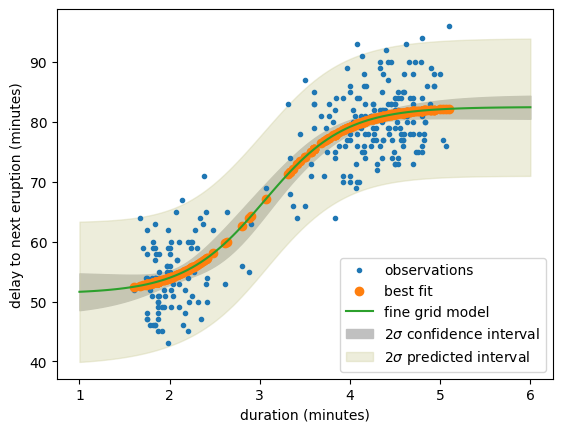

In [ ]:
plt.plot(tlen, delay, '.', label='observations')
plt.plot(tlen, lg.best_fit, 'o', label='best fit')
plt.plot(tfine, yfine, '-', label='fine grid model')
for i in range(lg.ny):
    plt.fill_between(
        tfine, yfine[:, i]-efine[:, i], yfine[:, i]+efine[:, i], color="#c0c0c0", label=r'$2\sigma$ confidence interval'
        )
    plt.fill_between(
        tfine, yfine[:, i]-pfine[:, i], yfine[:, i]+pfine[:, i], color="#d0d0a060", label=r'$2\sigma$ predicted interval'
        )


plt.xlabel('duration (minutes)')
plt.ylabel('delay to next eruption (minutes)')
plt.legend()
plt.show()

OR WITH `lmfit_global.simplefit` 

BUT ensure `independent_vars = ['x']` in defining `simplefit` `model`


Fit status smplefit:
Best-fit parameters:         [82.46594114 51.32199937  3.05526138  2.25391129]
Asymptotic error:            [0.99754082 1.8308565  0.11067302 0.43547958]

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 127
    # data points      = 272
    # variables        = 4
    chi-square         = 8469.42359
    reduced chi-square = 31.6023268
    Akaike info crit   = 943.249061
    Bayesian info crit = 957.672269
    R-squared          = 0.83090615
[[Variables]]
    amp:    82.4659411 +/- 0.99754082 (1.21%) (init = 90)
    off:    51.3219994 +/- 1.83085650 (3.57%) (init = 2)
    tau:    3.05526138 +/- 0.11067302 (3.62%) (init = 2)
    gamma:  2.25391129 +/- 0.43547958 (19.32%) (init = 50)
[[Correlations]] (unreported correlations are < 0.100)
    C(off, gamma) = +0.8634
    C(amp, gamma) = -0.7706
    C(off, tau)   = +0.7277
    C(amp, off)   = -0.5380
    C(tau, gamma) = +0.4699
[[Model]]
    Model(logistic_func2)
[[Fit Statistics]]
    # fitti

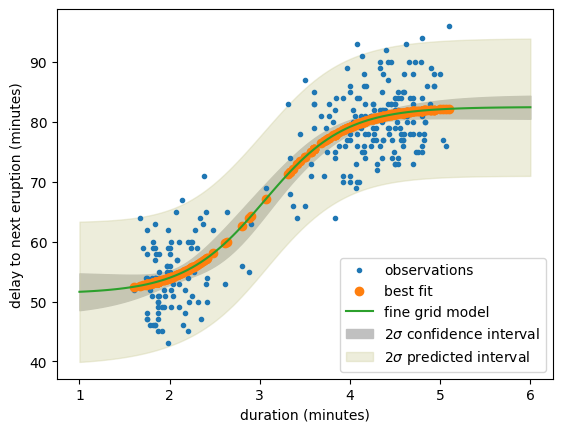

In [ ]:
def logistic_func2(x, amp, off, tau, gamma):
    return (amp-off)/(1+np.exp(-gamma*(x-tau))) + off  # ensure independent_vars = x

p0 = [90, 2, 2, 50]   # init params
### --- or in form of --- ###
# p0 = {
#     'amp': {'value':90, },
#     'off': {'value':2, },
#     'tau': {'value':2, },
#     'gamma': {'value':50, },
# }                     # init params

result = None
return_result = True
if return_result:
    popt, perr, result = simplefit(
        logistic_func2,
        p0=p0,
        x=tlen,
        y=delay,
        err=1.0,
        fit_method="leastsq",
        return_result=return_result
    )
else:
    popt, perr = simplefit(
        logistic_func2,
        p0=p0,
        x=tlen,
        y=delay,
        err=1.0,
        fit_method="leastsq",
        return_result=False
    )

print("\nFit status smplefit:")
print("====================")
print("Best-fit parameters:        ", popt)
print("Asymptotic error:           ", perr)
print()

if result:
    import lmfit
    print(lmfit.fit_report(result))

print(result.fit_report())

# make finely spaced grid of duration values, extending past data range
tfine = np.linspace(1, 6, 101)
yfine = result.eval(x=tfine)

# now calculate uncertainty interval and predicted interval for sigma=2, 95% level
efine = result.eval_uncertainty(x=tfine, sigma=2)
pfine = result.dely_predicted

plt.plot(tlen, delay, '.', label='observations')
plt.plot(tlen, result.best_fit, 'o', label='best fit')
plt.plot(tfine, yfine, '-', label='fine grid model')
plt.fill_between(tfine, yfine-efine, yfine+efine,
                 color="#c0c0c0", label=r'$2\sigma$ confidence interval')

plt.fill_between(tfine, yfine-pfine, yfine+pfine,
                 color="#d0d0a060", label=r'$2\sigma$ predicted interval')

plt.xlabel('duration (minutes)')
plt.ylabel('delay to next eruption (minutes)')
plt.legend()
plt.show()